##Regression analysis

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
print("done")

done


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager

In [42]:
#load Data
from sklearn.datasets import make_regression
x,y = make_regression(
    n_samples = 100000,
    n_features = 1,
    n_informative=1,
    n_targets=1,
    noise=10
)
x

array([[-0.79736646],
       [ 0.21890576],
       [-1.70450352],
       ...,
       [ 1.13319351],
       [-1.03262718],
       [ 0.17369461]], shape=(100000, 1))

In [43]:
#EDA
x=pd.DataFrame(x,columns=['Feature'])
x

,Feature
0,-0.797366
1,0.218906
2,-1.704504
3,0.401548
4,0.167212
...,...
99995,-1.140902
99996,-0.640557
99997,1.133194
99998,-1.032627


In [44]:
#get genral info
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Feature  100000 non-null  float64
dtypes: float64(1)
memory usage: 781.4 KB


In [45]:
#statistical values
x.describe()

,Feature
count,100000.000000
mean,-0.002755
std,1.003157
min,-4.630786
25%,-0.674074
50%,-0.004998
75%,0.671035
max,4.557321


Text(0.5, 1.0, 'Data')

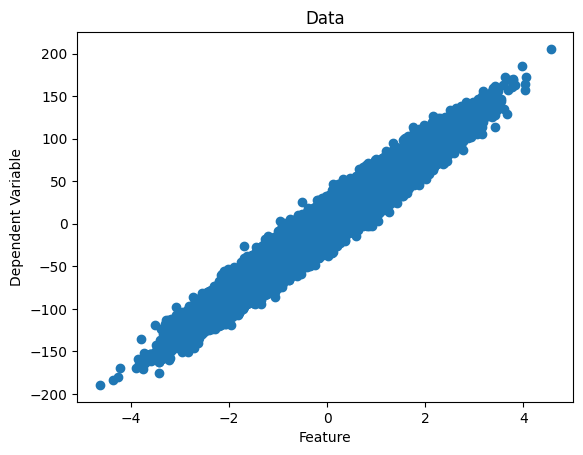

In [46]:
#visualization of data
plt.scatter(x['Feature'],y)
plt.xlabel("Feature")
plt.ylabel("Dependent Variable")
plt.title("Data")

In [47]:
#corelation analysis 
np.corrcoef(x['Feature'],y)

array([[1.        , 0.97319756],
       [0.97319756, 1.        ]])

In [48]:
# split the data testing(30%) and training(70%)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.70)

In [49]:
type(x_train)

pandas.core.frame.DataFrame

In [50]:
#train the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[42.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Feature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.02283
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [51]:
# Evaluate the Model
#predict value for test set
y_pred = model.predict(x_test)


In [52]:
#Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print(f"mean Absolute Error= {mae:.2f}")

mean Absolute Error= 8.03


In [53]:
#Mean Absolute Percentage Error
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test,y_pred)
print(f"mean Absolute % Error= {mape:.2f}")

mean Absolute % Error= 1.85


In [54]:
# Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
print(f"mean Squared Error= {mse:.2f}")

mean Squared Error= 101.02


In [55]:
 #root meanMean Squared Error
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test,y_pred)
print(f"root mean squared error : {rmse}")

root mean squared error : 10.050861241390802


In [56]:
#r2 score
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)
print(f"r2 score : {r2}")

r2 score : 0.9464834335911725
